For plotting two specific groups from Multiple_ss.py

In [1]:
import os
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgba
import seaborn as sns
import numpy as np
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
from scipy.stats import ks_2samp
sns.__version__
import glob
from matplotlib import patches
import matplotlib.colors as mcolors
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from itertools import combinations


In [16]:
#start with allstepsizes_modified.csv
all_data = pd.read_csv("/Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Composite_Data/StepSize_Dist/221104_221118_230103_230104_230105_allstepsizes_modified.csv")
identifier_str = "221104_221118_230103_230104_230105"
output_dir = "/Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Composite_Data/StepSize_Dist"

/var/folders/tn/mq6hmrjj03j8dxy2x5lk_1qw0000gn/T/ipykernel_87064/1281236904.py:2: DtypeWarning: Columns (5,57700,57701,57702) have mixed types. Specify dtype option on import or set low_memory=False.
  all_data = pd.read_csv("/Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Composite_Data/StepSize_Dist/221104_221118_230103_230104_230105_allstepsizes_modified.csv")


In [17]:
# Print available groups
unique_groups = all_data['group'].unique().tolist()
print("Unique groups found:", unique_groups)

Unique groups found: ['Uninfected', 'HSV-1', 'ICP4null', 'ICP8null', 'contact inhibited_HSV-1', 'contact inhibited_Uninfected', 'UVIA', '∆ICP27', 'HSV-1_CHX', 'Uninfected_CHX']


In [18]:
# === USER: Select any two groups from those printed above ===
selected_groups = ['Uninfected', 'HSV-1']  # groups to plot
colors = ['#000000', '#FF0066']  # your hex colors for each group

In [19]:
# Path to the angle distributions CSV
ss_csv = os.path.join(output_dir, f"{identifier_str}_stepsize_distributions.csv")

# Histogram parameters
min_pts = 0
max_ss = 1  # microns
bin_size = 0.02

# --- Load or create data ---
if os.path.exists(ss_csv):
    print(f"Found existing step size distributions CSV. Loading: {ss_csv}")
    new_df = pd.read_csv(ss_csv)
    copy_all = new_df.copy()
else:
    print("No angle CSV found — generating distributions...")
    copy_all = all_data.copy()
    copy_all = copy_all[copy_all['group'].isin(selected_groups)]
    copy_all = copy_all.replace('', np.NaN)
    copy_all.dropna(axis=0, subset=['group'], inplace=True)

    start_pos = copy_all.columns.get_loc("0")
    stop_pos = len(copy_all.columns) - start_pos - 1
    step_cols = copy_all.columns[start_pos:start_pos + stop_pos]

    data_arr = []
    for tlag in copy_all['tlag'].unique():
        for bin_left in np.arange(0, max_ss + bin_size, bin_size):
            data_arr.append([tlag, bin_left])
    new_df = pd.DataFrame(data_arr, columns=['tlag', 'bin'])

    for group in selected_groups:
        new_df[f"{group}-prop"] = 0
        new_df[f"{group}-count"] = 0
        new_df[f"{group}-total"] = 0
        for tlag in copy_all['tlag'].unique():
            cur_df = copy_all[(copy_all['group'] == group) & (copy_all['tlag'] == tlag)]
            obs_dist = pd.to_numeric(cur_df.loc[:, step_cols].to_numpy().flatten(), errors='coerce')
            obs_dist = obs_dist[~np.isnan(obs_dist)]

            new_df.loc[(new_df['tlag'] == tlag), f"{group}-total"] = len(obs_dist)
            if len(obs_dist) > min_pts:
                n = len(obs_dist)
                counts, bins = np.histogram(obs_dist, bins=np.arange(0, max_ss + bin_size, bin_size))
                for i, val in enumerate(counts):
                    new_df.loc[(new_df['tlag'] == tlag) & (new_df['bin'] == bins[i]), f"{group}-prop"] = val / n
                    new_df.loc[(new_df['tlag'] == tlag) & (new_df['bin'] == bins[i]), f"{group}-count"] = val

    new_df.to_csv(ss_csv, index=False)
    print(f"Saved new CSV: {ss_csv}")

Found existing step size distributions CSV. Loading: /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Composite_Data/StepSize_Dist/221104_221118_230103_230104_230105_stepsize_distributions.csv


Saved overlay KDE plot: /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Composite_Data/StepSize_Dist/221104_221118_230103_230104_230105_superimposed_plot_Uninfected-HSV-1_ss_overlay.png


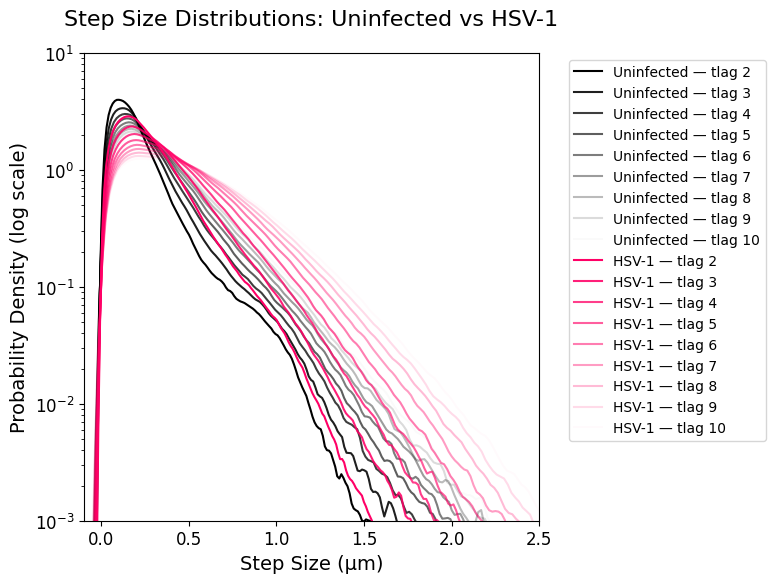

In [20]:
# --- Plot overlaid groups ---
plt.rcParams['font.size'] = 12

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

group_labels = []
second_moments = []
alpha2s = []

alpha_min = 0.02
alpha_max = 1.0

for color, group in zip(colors, selected_groups):
    copy_all_group = all_data[all_data['group'] == group]
    copy_all_group = copy_all_group.replace('', np.NaN)
    copy_all_group.dropna(axis=0, subset=['group'], inplace=True)

    start_pos = copy_all_group.columns.get_loc("0")
    stop_pos = len(copy_all_group.columns) - start_pos - 1
    step_cols = copy_all.columns[start_pos:start_pos + stop_pos]

    # Get tlags and remove tlag = 1
    my_tlags = sorted(copy_all_group['tlag'].unique())  # <- SORTED
    my_tlags = [t for t in my_tlags if t != 1] #this removes tlag=1
    n_tlags = len(my_tlags)

    # Precompute alphas only for tlags being plotted
    alphas = np.linspace(alpha_max, alpha_min, n_tlags)
    tlag_to_alpha = dict(zip(my_tlags, alphas))

    for tlag in my_tlags:
        cur_df = copy_all_group[copy_all_group['tlag'] == tlag]
        obs_dist = pd.to_numeric(cur_df.iloc[:, start_pos:start_pos + stop_pos].values.flatten(), errors='coerce')
        obs_dist = obs_dist[~np.isnan(obs_dist)]

        if len(obs_dist) > min_pts:
            # transparency by tlag (larger tlag = lighter)
            alpha_val = tlag_to_alpha[tlag]  

            # plot distribution
            sns.kdeplot(
                data=obs_dist,
                ax=ax,
                label=f"{group} — tlag {tlag}",
                color=color,
                alpha=alpha_val,
                linewidth=1.5
            )

            # calculate 2nd moment (alpha2 parameter)
            second_moment = np.mean(obs_dist ** 4) / (3 * (np.mean(obs_dist ** 2) ** 2)) - 1
            second_moments.append(second_moment)
            alpha2s.append(second_moment)
            group_labels.append(group)

# --- Format KDE overlay plot ---
ax.set_title(f'Step Size Distributions: {selected_groups[0]} vs {selected_groups[1]}', fontsize=16, pad=20)
ax.set_ylim(0.001, 10)
ax.set_xlim(-0.1, 2.5)
ax.set_xlabel('Step Size (μm)', fontsize=14)
ax.set_ylabel('Probability Density (log scale)', fontsize=14)
ax.set_yscale('log')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()

# Save overlay KDE plot
overlay_path = f"{output_dir}/{identifier_str}_superimposed_plot_{selected_groups[0]}-{selected_groups[1]}_ss_overlay.png"
plt.savefig(overlay_path, bbox_inches='tight')
print(f"Saved overlay KDE plot: {overlay_path}")
plt.show()


Running KS tests for step size distributions: ICP4_none vs ICP4_dox
✅ Saved KS test results: /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Composite_Data/StepSize_Dist/230711_240313_240827_240926_KS-step_ICP4_none-ICP4_dox.csv


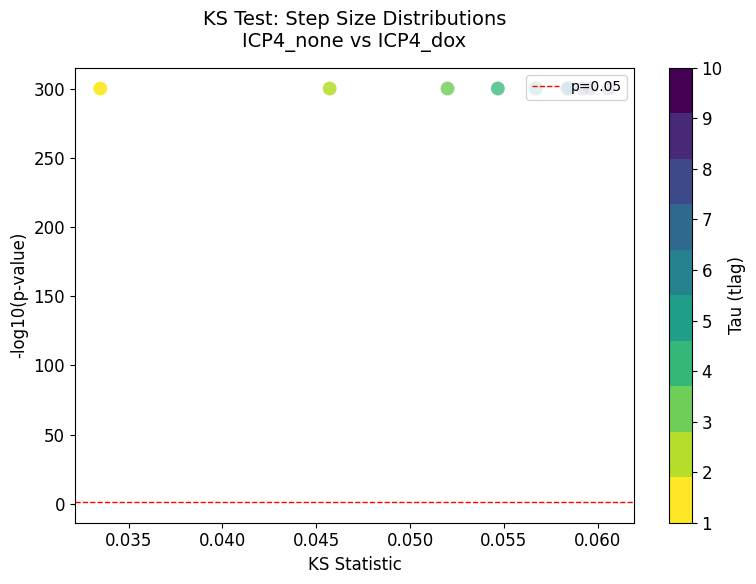

✅ Saved KS volcano plot: /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Composite_Data/StepSize_Dist/230711_240313_240827_240926_KS-step_ICP4_none-ICP4_dox_volcano.png


In [21]:
# === Run KS test on step size distributions ===
group1, group2 = selected_groups
print(f"Running KS tests for step size distributions: {group1} vs {group2}")

# Prepare data
copy_all = all_data.copy()
copy_all = copy_all[copy_all['group'].isin(selected_groups)]
copy_all = copy_all.replace('', np.NaN)
copy_all.dropna(axis=0, subset=['group'], inplace=True)

# Identify step size columns and tlags
start_pos = copy_all.columns.get_loc("0")
stop_pos = len(copy_all.columns) - start_pos - 1
step_cols = copy_all.columns[start_pos:start_pos + stop_pos]
my_tlags = sorted(copy_all['tlag'].unique())

# Extract subsets per group
data_group1 = copy_all[copy_all['group'] == group1]
data_group2 = copy_all[copy_all['group'] == group2]

# Initialize storage
statistics = []
p_values = []
valid_tlags = []

# Loop through tlags
for tlag in my_tlags:
    obs1 = pd.to_numeric(
        data_group1[data_group1['tlag'] == tlag].loc[:, step_cols].to_numpy().flatten(),
        errors='coerce'
    )
    obs2 = pd.to_numeric(
        data_group2[data_group2['tlag'] == tlag].loc[:, step_cols].to_numpy().flatten(),
        errors='coerce'
    )
    obs1 = obs1[~np.isnan(obs1)]
    obs2 = obs2[~np.isnan(obs2)]

    if len(obs1) > min_pts and len(obs2) > min_pts:
        stat, pval = ks_2samp(obs1, obs2)
        # Avoid log10(0) by clamping p-values to a small number
        pval = max(pval, 1e-300)
        statistics.append(stat)
        p_values.append(pval)
        valid_tlags.append(tlag)
    else:
        print(f"Skipping tlag={tlag} (insufficient data: {len(obs1)}, {len(obs2)})")

# --- Save KS results ---
ks_results = pd.DataFrame({
    "tlag": valid_tlags,
    "KS_statistic": statistics,
    "pvalue": p_values,
    "-log10_pvalue": -np.log10(p_values)
})
ks_outpath = f"{output_dir}/{identifier_str}_KS-step_{group1}-{group2}.csv"
ks_results.to_csv(ks_outpath, index=False)
print(f"✅ Saved KS test results: {ks_outpath}")

# --- Volcano plot ---
plt.figure(figsize=(8, 6))

# Colormap scaled by tau
colors = plt.cm.viridis(np.linspace(0, 1, len(valid_tlags)))[::-1]
cmap = ListedColormap(colors)
max_tau = max(valid_tlags)
tau_transparency = [0.4 + 0.6*(1 - tau/max_tau) for tau in valid_tlags]  # more consistent alpha

scatter = plt.scatter(
    statistics,
    -np.log10(p_values),
    c=valid_tlags,
    cmap=cmap,
    alpha=tau_transparency,
    s=100,
    edgecolor='none'
)

plt.title(f'KS Test: Step Size Distributions\n{group1} vs {group2}', fontsize=14, pad=15)
plt.xlabel('KS Statistic', fontsize=12)
plt.ylabel('-log10(p-value)', fontsize=12)
plt.axhline(-np.log10(0.05), color='red', linestyle='--', linewidth=1, label='p=0.05')
plt.legend(loc='upper right', fontsize=10)
plt.grid(False)

# Colorbar for tlag
cbar = plt.colorbar(scatter)
cbar.set_label('Tau (tlag)', fontsize=12)

plt.tight_layout()
volcano_path = f"{output_dir}/{identifier_str}_KS-step_{group1}-{group2}_volcano.png"
plt.savefig(volcano_path, bbox_inches='tight')
plt.show()

print(f"✅ Saved KS volcano plot: {volcano_path}")


Saved Alpha2 plot: /Volumes/mohrlab/mohrlabspace/Nora_Mohr/ANALYSIS/Composite_Data/StepSize_Dist/221104_221118_230103_230104_230105_HSV-1-Uninfected_alpha2.png


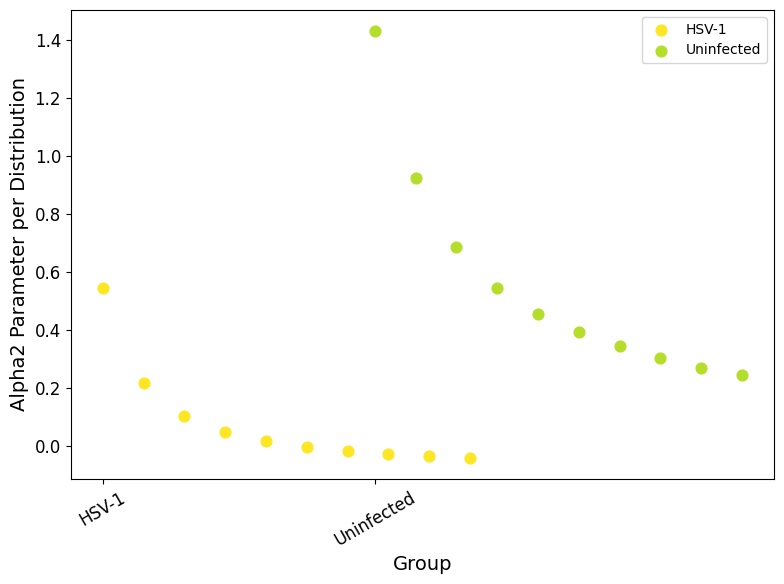

In [12]:
# --- Plot Alpha2 summary ---
plt.figure(figsize=(8, 6))
scatter_width = 0.15

for color, group in zip(colors, selected_groups):
    indices = [idx for idx, label in enumerate(group_labels) if label == group]
    x_coords = [selected_groups.index(group) + idx * scatter_width for idx in range(len(indices))]
    plt.scatter(x_coords, [alpha2s[idx] for idx in indices], label=group, color=color, s=60)

plt.xlabel('Group', fontsize=14)
plt.ylabel('Alpha2 Parameter per Distribution', fontsize=14)
plt.xticks(range(len(selected_groups)), selected_groups, rotation=30)
plt.legend(fontsize=10)
plt.tight_layout()

alpha2_path = f"{output_dir}/{identifier_str}_{selected_groups[0]}-{selected_groups[1]}_alpha2.png"
plt.savefig(alpha2_path, bbox_inches='tight')
print(f"Saved Alpha2 plot: {alpha2_path}")
plt.show()